# Lesson 11 — NN Surrogate with Deep Ensembles

**Goal**: Train 5 independent MLPs from different random seeds. Average their predictions to get μ(x). Compute the standard deviation across members to get σ(x). This is a *better-calibrated* alternative to MC Dropout and is used as the primary comparison in Lesson 12.

**Reference**: Lakshminarayanan et al. (2017): *Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import norm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

print('Libraries loaded.')

Libraries loaded.


## Forrester benchmark function

The 1D test function used throughout the course: `f(x) = (6x-2)² sin(12x-4)` on [0, 1].  
It has one global minimum near x ≈ 0.76 and a local minimum near x ≈ 0.1.

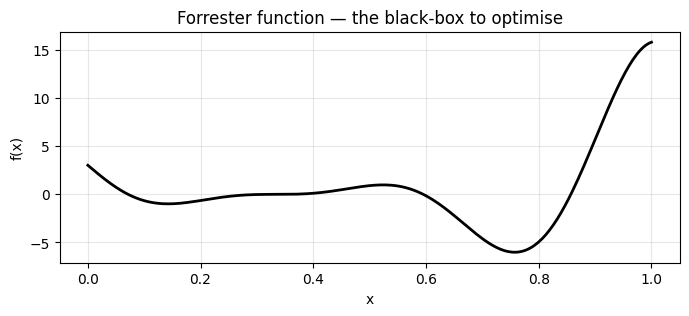

In [2]:
def forrester(x):
    x = np.asarray(x).ravel()
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)

xs = np.linspace(0, 1, 300)
plt.figure(figsize=(8, 3))
plt.plot(xs, forrester(xs), color='black', linewidth=2)
plt.title('Forrester function — the black-box to optimise'); plt.xlabel('x'); plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.show()

## Model definitions

### MLP — one ensemble member

A plain two-hidden-layer network with **no dropout**. Diversity comes entirely from the random seed used to initialise the weights — not from dropout noise.

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim=1, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

print('MLP defined. No dropout — each member is deterministic at inference.')

MLP defined. No dropout — each member is deterministic at inference.


### DeepEnsemble — the surrogate

- **`__init__`**: Create N MLPs; use `torch.manual_seed(i * 100)` before each so each member has a different random initialisation.
- **`fit`**: Train each member independently with its own optimizer.
- **`predict`**: Run all members with `model.eval()` (deterministic), return mean and std.
- **`predict_each`**: Return individual predictions — needed for Part 1 visualisation.

In [4]:
class DeepEnsemble:
    def __init__(self, n_members=5, input_dim=1, hidden=64):
        self.n_members  = n_members
        self.members    = []
        self.all_losses = []
        for i in range(n_members):
            torch.manual_seed(i * 100)   # different init per member
            self.members.append(MLP(input_dim, hidden))

    def fit(self, X_tr, y_tr, n_epochs=3000, lr=1e-3):
        loss_fn = nn.MSELoss()
        self.all_losses = []
        for i, model in enumerate(self.members):
            opt    = optim.Adam(model.parameters(), lr=lr)
            losses = []
            for _ in range(n_epochs):
                model.train()
                opt.zero_grad()
                loss = loss_fn(model(X_tr).squeeze(), y_tr)
                loss.backward()
                opt.step()
                losses.append(loss.item())
            self.all_losses.append(losses)
            print(f'  Member {i+1}/{self.n_members}  final loss: {losses[-1]:.6f}')
        return self.all_losses

    def predict(self, x):
        preds = []
        for model in self.members:
            model.eval()
            with torch.no_grad():
                preds.append(model(x).squeeze())
        preds = torch.stack(preds)   # (N, n_points)
        return preds.mean(0), preds.std(0)

    def predict_each(self, x):
        preds = []
        for model in self.members:
            model.eval()
            with torch.no_grad():
                preds.append(model(x).squeeze().numpy())
        return np.array(preds)   # (N, n_points)

print('DeepEnsemble defined.')

DeepEnsemble defined.


## Training data and standardisation

15 random points from the Forrester domain. We standardise X and y using the training-set statistics before fitting — same practice as Lesson 10.

In [5]:
n_train = 15
X_np    = rng.uniform(0, 1, (n_train, 1)).astype(np.float32)
y_np    = forrester(X_np).astype(np.float32)

Xm, Xs  = float(X_np.mean()), float(X_np.std())
ym, ys  = float(y_np.mean()), float(y_np.std())

def to_tensor(arr):
    return torch.from_numpy(arr.astype(np.float32))

X_tr = to_tensor((X_np - Xm) / Xs)
y_tr = to_tensor((y_np - ym) / ys)

x_dense   = np.linspace(0, 1, 300).astype(np.float32)
y_true    = forrester(x_dense)
x_dense_t = to_tensor((x_dense.reshape(-1, 1) - Xm) / Xs)

print(f'Training data: {n_train} points,  y range [{y_np.min():.2f}, {y_np.max():.2f}]')
print(f'Standardisation: Xm={Xm:.3f} Xs={Xs:.3f}  ym={ym:.3f} ys={ys:.3f}')

Training data: 15 points,  y range [-6.01, 14.69]
Standardisation: Xm=0.611 Xs=0.267  ym=-0.210 ys=5.433


## Train the ensemble

Each member runs its own training loop. Training 5 members × 3000 epochs takes a few seconds.

In [6]:
N_MEMBERS = 5
print(f'Training Deep Ensemble ({N_MEMBERS} members × 3000 epochs)...')
ensemble  = DeepEnsemble(n_members=N_MEMBERS, input_dim=1, hidden=64)
all_losses = ensemble.fit(X_tr, y_tr, n_epochs=3000)

mu_s, std_s = ensemble.predict(x_dense_t)
mu_de  = mu_s.numpy()  * ys + ym
std_de = std_s.numpy() * ys

member_preds = ensemble.predict_each(x_dense_t)   # (N, 300)
member_preds = member_preds * ys + ym             # un-standardise
print('Done.')

Training Deep Ensemble (5 members × 3000 epochs)...
  Member 1/5  final loss: 0.000000
  Member 2/5  final loss: 0.000023
  Member 3/5  final loss: 0.000014
  Member 4/5  final loss: 0.000014
  Member 5/5  final loss: 0.000023
Done.


---
## Part 1 — Ensemble diversity

Each member learned a slightly different function because each started from different random weights. The *disagreement between members* is the source of the uncertainty estimate.

**Key idea**: no single member is trusted absolutely — the spread across members tells us where the prediction is uncertain.

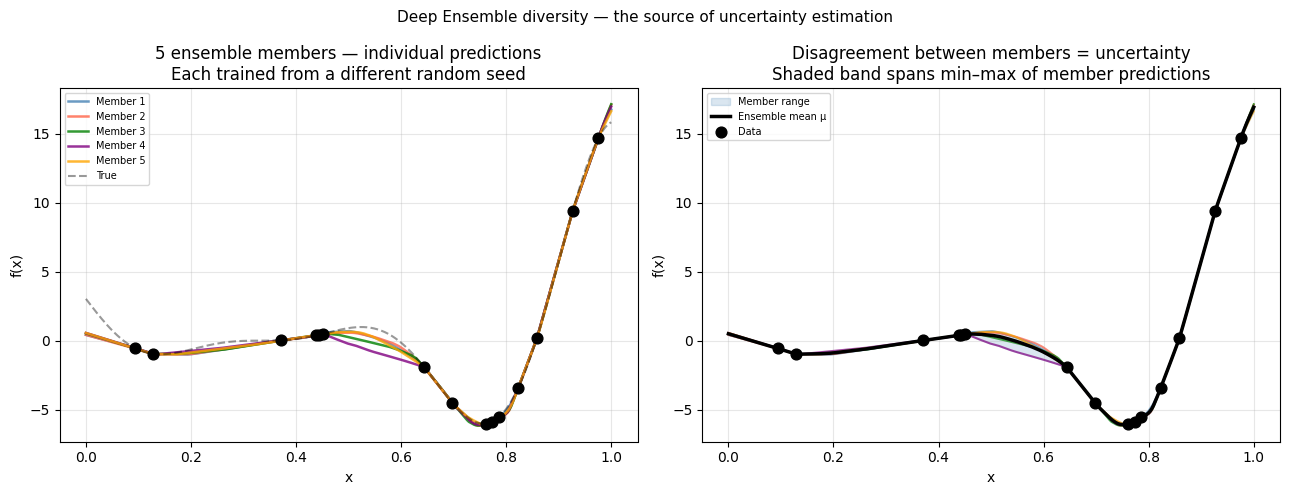

In [7]:
colors = ['steelblue', 'tomato', 'green', 'purple', 'orange']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (pred, color) in enumerate(zip(member_preds, colors)):
    axes[0].plot(x_dense, pred, color=color, linewidth=1.8, alpha=0.8, label=f'Member {i+1}')
axes[0].plot(x_dense, y_true, color='black', linestyle='--', linewidth=1.5, alpha=0.4, label='True')
axes[0].scatter(X_np.squeeze(), y_np, color='black', s=60, zorder=5)
axes[0].set_title('5 ensemble members — individual predictions\nEach trained from a different random seed')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)'); axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].fill_between(x_dense, member_preds.min(0), member_preds.max(0),
                     alpha=0.2, color='steelblue', label='Member range')
for i, (pred, color) in enumerate(zip(member_preds, colors)):
    axes[1].plot(x_dense, pred, color=color, linewidth=1.5, alpha=0.7)
axes[1].plot(x_dense, mu_de, color='black', linewidth=2.5, label='Ensemble mean μ')
axes[1].scatter(X_np.squeeze(), y_np, color='black', s=60, zorder=5, label='Data')
axes[1].set_title('Disagreement between members = uncertainty\nShaded band spans min–max of member predictions')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)'); axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.suptitle('Deep Ensemble diversity — the source of uncertainty estimation', fontsize=11)
plt.tight_layout()
plt.show()

**Observation**: Members agree near dense regions (uncertainty = 0) and diverge in the gaps (uncertainty > 0). This is the ideal behaviour for a surrogate used in Bayesian Optimisation.

> **Exercise 1**: Change `n_members=2` in the cell above and re-run. Does the uncertainty estimate become less reliable? Try `n_members=10`.

---
## Part 2 — Combined mean and uncertainty

- **μ(x)** = average prediction across all 5 members
- **σ(x)** = standard deviation across all 5 members
- **±2σ band** covers ≈95% of the ensemble's spread

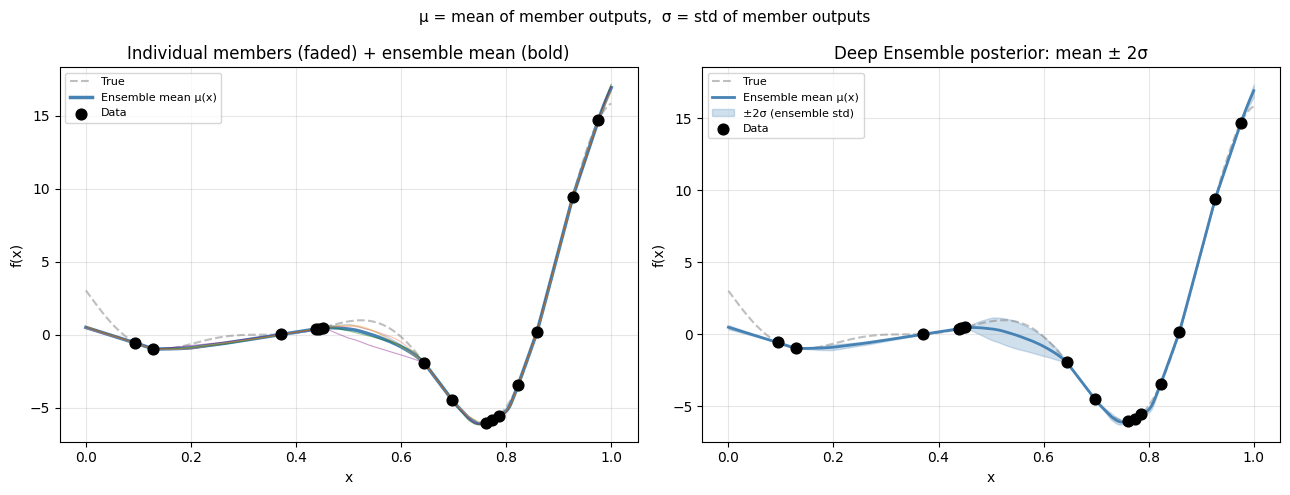

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_dense, y_true, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='True')
axes[0].plot(x_dense, mu_de, color='steelblue', linewidth=2.5, label='Ensemble mean μ(x)')
for i, (pred, color) in enumerate(zip(member_preds, colors)):
    axes[0].plot(x_dense, pred, color=color, linewidth=0.8, alpha=0.4)
axes[0].scatter(X_np.squeeze(), y_np, color='black', s=60, zorder=5, label='Data')
axes[0].set_title('Individual members (faded) + ensemble mean (bold)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_dense, y_true, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='True')
axes[1].plot(x_dense, mu_de, color='steelblue', linewidth=2, label='Ensemble mean μ(x)')
axes[1].fill_between(x_dense, mu_de - 2*std_de, mu_de + 2*std_de,
                     alpha=0.25, color='steelblue', label='±2σ (ensemble std)')
axes[1].scatter(X_np.squeeze(), y_np, color='black', s=60, zorder=5, label='Data')
axes[1].set_title('Deep Ensemble posterior: mean ± 2σ')
axes[1].set_xlabel('x'); axes[1].set_ylabel('f(x)'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('μ = mean of member outputs,  σ = std of member outputs', fontsize=11)
plt.tight_layout()
plt.show()

---
## Part 3 — Uncertainty calibration

A well-calibrated surrogate has **small σ near data** and **large σ in unexplored regions**. The bottom panel shows σ(x) directly — vertical ticks mark the training point locations.

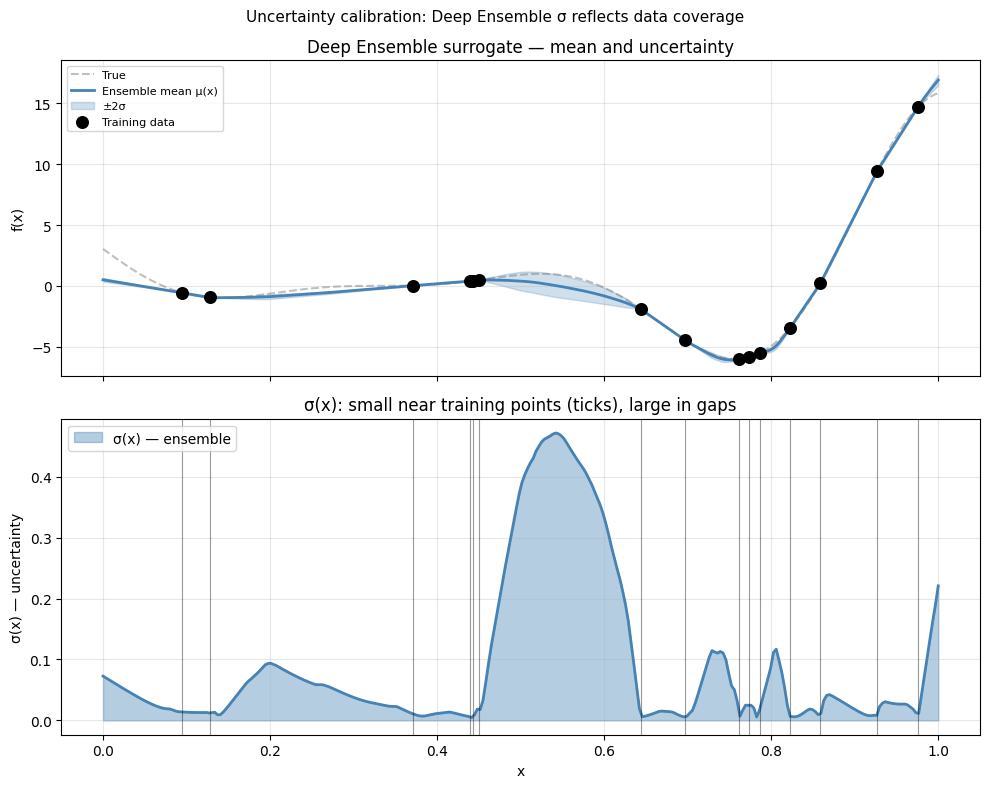

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(x_dense, y_true, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='True')
axes[0].plot(x_dense, mu_de, color='steelblue', linewidth=2, label='Ensemble mean μ(x)')
axes[0].fill_between(x_dense, mu_de - 2*std_de, mu_de + 2*std_de,
                     alpha=0.25, color='steelblue', label='±2σ')
axes[0].scatter(X_np.squeeze(), y_np, color='black', s=70, zorder=5, label='Training data')
axes[0].set_ylabel('f(x)'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Deep Ensemble surrogate — mean and uncertainty')

axes[1].fill_between(x_dense, 0, std_de, alpha=0.4, color='steelblue', label='σ(x) — ensemble')
axes[1].plot(x_dense, std_de, color='steelblue', linewidth=2)
for xi in X_np.squeeze():
    axes[1].axvline(xi, color='black', linewidth=0.8, alpha=0.4)
axes[1].set_ylabel('σ(x) — uncertainty'); axes[1].set_xlabel('x')
axes[1].set_title('σ(x): small near training points (ticks), large in gaps')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Uncertainty calibration: Deep Ensemble σ reflects data coverage', fontsize=11)
plt.tight_layout()
plt.show()

> **Exercise 2**: Compare this σ(x) curve with the one from MC Dropout (Lesson 10 Part 3) on the same training data. Which gives larger uncertainty in the gaps?

---
## Part 4 — Training: 5 loss curves

Each member is trained independently. They all converge to similar final losses, but with slight differences — those differences in the learned parameters are what create the diversity in predictions.

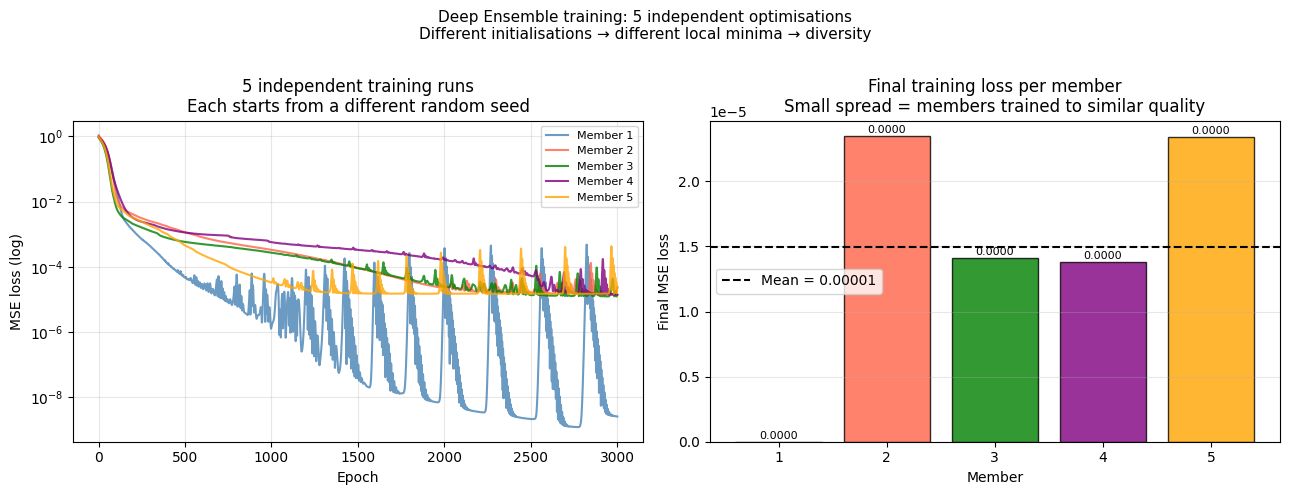

Final losses: ['0.00000', '0.00002', '0.00001', '0.00001', '0.00002']


In [10]:
epochs = np.arange(1, 3001)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (losses, color) in enumerate(zip(all_losses, colors)):
    axes[0].semilogy(epochs, losses, color=color, linewidth=1.5, alpha=0.8, label=f'Member {i+1}')
axes[0].set_title('5 independent training runs\nEach starts from a different random seed')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE loss (log)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

final_losses = [l[-1] for l in all_losses]
axes[1].bar(range(1, N_MEMBERS+1), final_losses, color=colors, alpha=0.8, edgecolor='black')
axes[1].axhline(np.mean(final_losses), color='black', linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(final_losses):.5f}')
axes[1].set_title('Final training loss per member\nSmall spread = members trained to similar quality')
axes[1].set_xlabel('Member'); axes[1].set_ylabel('Final MSE loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(final_losses):
    axes[1].text(i+1, v + max(final_losses)*0.01, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle('Deep Ensemble training: 5 independent optimisations\nDifferent initialisations → different local minima → diversity', fontsize=11)
plt.tight_layout()
plt.show()

print('Final losses:', [f'{l:.5f}' for l in final_losses])

---
## Part 5 — Deep Ensembles vs MC Dropout

Both surrogates are fitted to the same 15 training points. We compare:
- **Method A (MC Dropout)**: stochasticity at inference via dropout, single network, T=50 passes
- **Method B (Deep Ensembles)**: diversity at training time via different seeds, N networks, deterministic inference

Deep Ensembles typically produce **wider, better-calibrated** uncertainty.

In [11]:
class MCDropoutMLP(nn.Module):
    def __init__(self, input_dim=1, hidden=64, dropout_rate=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden, hidden),    nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

    def mc_predict(self, x, n_passes=50):
        self.train()   # keep dropout ON
        with torch.no_grad():
            preds = torch.stack([self(x) for _ in range(n_passes)])
        return preds.mean(0).squeeze(), preds.std(0).squeeze()

def train_single(model, X_tr, y_tr, n_epochs=3000, lr=1e-3):
    opt, loss_fn, losses = optim.Adam(model.parameters(), lr=lr), nn.MSELoss(), []
    for _ in range(n_epochs):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(X_tr).squeeze(), y_tr)
        loss.backward(); opt.step(); losses.append(loss.item())
    return losses

torch.manual_seed(RANDOM_SEED)
mc_model = MCDropoutMLP(input_dim=1, hidden=64, dropout_rate=0.1)
print('Training MC Dropout MLP...')
train_single(mc_model, X_tr, y_tr, n_epochs=3000)

mu_mc_s, std_mc_s = mc_model.mc_predict(x_dense_t, n_passes=50)
mu_mc  = mu_mc_s.numpy() * ys + ym
std_mc = std_mc_s.numpy() * ys

print('Done.')

Training MC Dropout MLP...
Done.


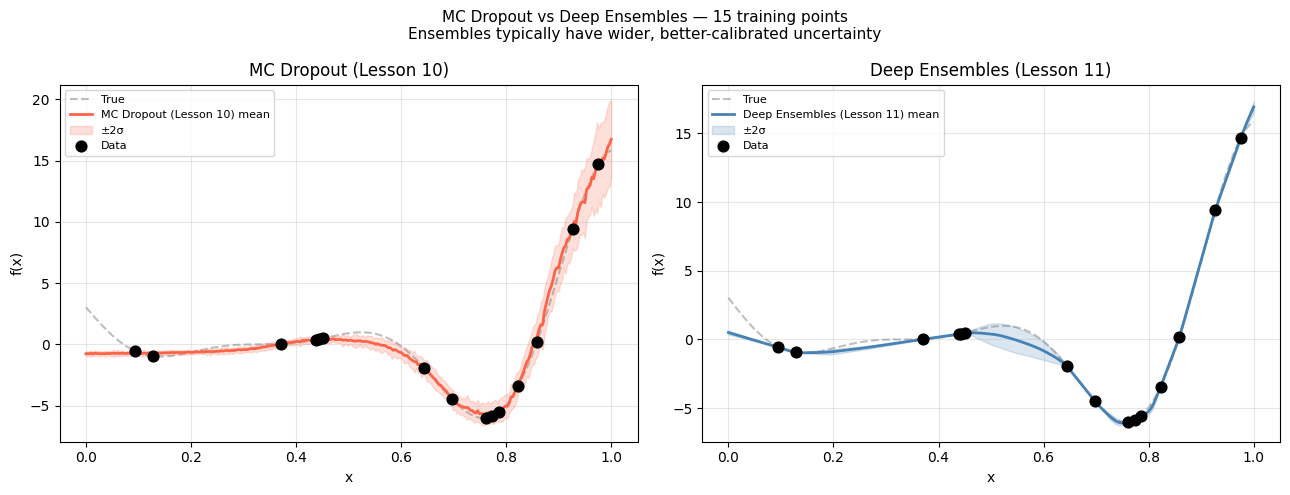

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (mu, std, label, color) in zip(axes, [
    (mu_mc, std_mc, 'MC Dropout (Lesson 10)',    'tomato'),
    (mu_de, std_de, 'Deep Ensembles (Lesson 11)', 'steelblue'),
]):
    ax.plot(x_dense, y_true, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='True')
    ax.plot(x_dense, mu, color=color, linewidth=2, label=f'{label} mean')
    ax.fill_between(x_dense, mu - 2*std, mu + 2*std, alpha=0.2, color=color, label='±2σ')
    ax.scatter(X_np.squeeze(), y_np, color='black', s=60, zorder=5, label='Data')
    ax.set_title(label)
    ax.set_xlabel('x'); ax.set_ylabel('f(x)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'MC Dropout vs Deep Ensembles — {n_train} training points\nEnsembles typically have wider, better-calibrated uncertainty', fontsize=11)
plt.tight_layout()
plt.show()

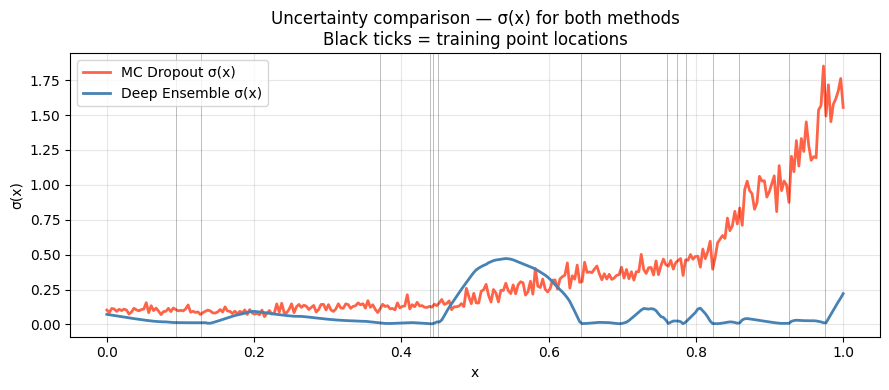

In [13]:
# σ(x) comparison on the same axes
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_dense, std_mc, color='tomato',    linewidth=2, label='MC Dropout σ(x)')
ax.plot(x_dense, std_de, color='steelblue', linewidth=2, label='Deep Ensemble σ(x)')
for xi in X_np.squeeze():
    ax.axvline(xi, color='black', linewidth=0.6, alpha=0.3)
ax.set_title('Uncertainty comparison — σ(x) for both methods\nBlack ticks = training point locations')
ax.set_xlabel('x'); ax.set_ylabel('σ(x)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 6 — One BO step with Deep Ensembles

We replace the GP with the Deep Ensemble in a single Bayesian Optimisation step:

1. **Fit** the ensemble on current data
2. **Compute EI** from ensemble μ and σ
3. **Evaluate** f at x_next
4. **Update** the dataset and refit

The loop structure is identical to Lessons 8 and 10 — only the surrogate changed.

In [14]:
def acq_ei(mu, std, f_best, xi=0.01):
    from scipy.stats import norm
    Z = (f_best - xi - mu) / (std + 1e-9)
    return np.maximum((f_best - xi - mu) * norm.cdf(Z) + std * norm.pdf(Z), 0)

f_best   = float(y_np.min())
ei_de    = acq_ei(mu_de, std_de, f_best, xi=0.01)
idx_next = int(np.argmax(ei_de))
x_next   = float(x_dense[idx_next])
y_next   = forrester(np.array([x_next])).item()

print(f'Current best f* = {f_best:.4f}')
print(f'x_next = {x_next:.4f}  →  f(x_next) = {y_next:.4f}')

Current best f* = -6.0126
x_next = 0.7559  →  f(x_next) = -6.0197


In [15]:
# Refit ensemble with the new point
X_new    = np.vstack([X_np, [[x_next]]]).astype(np.float32)
y_new    = np.append(y_np, y_next).astype(np.float32)
Xm2, Xs2 = float(X_new.mean()), float(X_new.std())
ym2, ys2 = float(y_new.mean()), float(y_new.std())
X_tr2    = to_tensor((X_new - Xm2) / Xs2)
y_tr2    = to_tensor((y_new - ym2) / ys2)

print(f'Refitting ensemble on {len(X_new)} points...')
ensemble2 = DeepEnsemble(n_members=N_MEMBERS, input_dim=1, hidden=64)
ensemble2.fit(X_tr2, y_tr2, n_epochs=3000)

x_dense_t2    = to_tensor((x_dense.reshape(-1, 1) - Xm2) / Xs2)
mu2_s, std2_s = ensemble2.predict(x_dense_t2)
mu2  = mu2_s.numpy() * ys2 + ym2
std2 = std2_s.numpy() * ys2

print(f'f_best improved: {f_best:.3f} → {float(y_new.min()):.3f}')

Refitting ensemble on 16 points...
  Member 1/5  final loss: 0.000001
  Member 2/5  final loss: 0.000012
  Member 3/5  final loss: 0.000024
  Member 4/5  final loss: 0.000000
  Member 5/5  final loss: 0.000028
f_best improved: -6.013 → -6.020


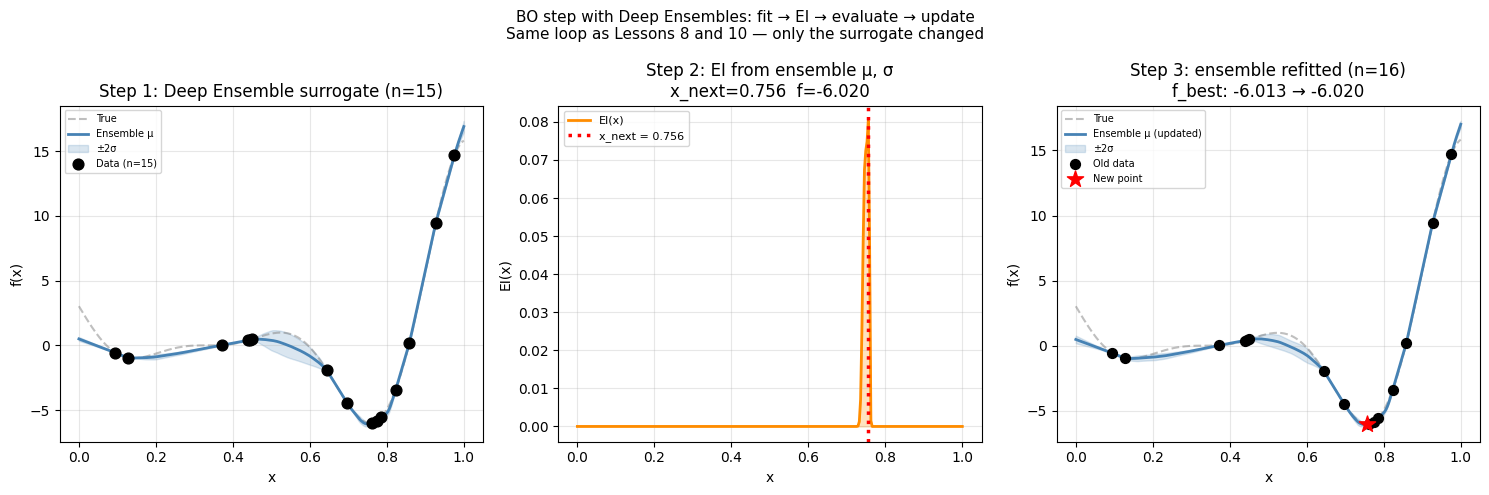

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x_dense, y_true, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='True')
axes[0].plot(x_dense, mu_de, color='steelblue', linewidth=2, label='Ensemble μ')
axes[0].fill_between(x_dense, mu_de-2*std_de, mu_de+2*std_de, alpha=0.2, color='steelblue', label='±2σ')
axes[0].scatter(X_np.squeeze(), y_np, color='black', s=60, zorder=5, label=f'Data (n={n_train})')
axes[0].set_title(f'Step 1: Deep Ensemble surrogate (n={n_train})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)'); axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_dense, ei_de, color='darkorange', linewidth=2, label='EI(x)')
axes[1].fill_between(x_dense, 0, ei_de, alpha=0.25, color='darkorange')
axes[1].axvline(x_next, color='red', linewidth=2.5, linestyle=':', label=f'x_next = {x_next:.3f}')
axes[1].set_title(f'Step 2: EI from ensemble μ, σ\nx_next={x_next:.3f}  f={y_next:.3f}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('EI(x)'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(x_dense, y_true, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='True')
axes[2].plot(x_dense, mu2, color='steelblue', linewidth=2, label='Ensemble μ (updated)')
axes[2].fill_between(x_dense, mu2-2*std2, mu2+2*std2, alpha=0.2, color='steelblue', label='±2σ')
axes[2].scatter(X_np.squeeze(), y_np, color='black', s=50, zorder=5, label='Old data')
axes[2].scatter([x_next], [y_next], color='red', s=150, zorder=6, marker='*', label='New point')
axes[2].set_title(f'Step 3: ensemble refitted (n={len(X_new)})\nf_best: {f_best:.3f} → {float(y_new.min()):.3f}')
axes[2].set_xlabel('x'); axes[2].set_ylabel('f(x)'); axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3)

plt.suptitle('BO step with Deep Ensembles: fit → EI → evaluate → update\nSame loop as Lessons 8 and 10 — only the surrogate changed', fontsize=11)
plt.tight_layout()
plt.show()

> **Exercise 3**: Run 15 BO iterations with Deep Ensembles on Forrester. Does it converge at the same rate as GP-BO from Lesson 8?

---
## Summary

| | MC Dropout (Lesson 10) | Deep Ensembles (Lesson 11) |
|---|---|---|
| **Architecture** | 1 MLP + Dropout(0.1) | N plain MLPs |
| **Uncertainty source** | Dropout noise at inference | Weight diversity from different seeds |
| **Inference** | `model.train()` + T passes | `model.eval()` × N members |
| **Training cost** | 1× | N× |
| **Calibration** | Good | Better |
| **Reference** | Gal & Ghahramani 2016 | Lakshminarayanan et al. 2017 |

**What's next**: Lesson 12 compares both methods head-to-head against GP on Forrester and Branin. Convergence curves, uncertainty calibration, and computational cost — the core results of the paper.